# The S₃ fermion sector: verifying the LFVHD draft, and adding quarks

**A research notebook, not a tutorial.** It continues
[`01_scalar_parameter_space.ipynb`](01_scalar_parameter_space.ipynb) (the scalar sector)
and takes its physics input from [`LFVHD_3HDMS3.tex`](LFVHD_3HDMS3.tex) — the draft
*"Exploring LFV Higgs decays in the Three Higgs Doublet Model"* [LFVHD], which supplies the
S₃ assignment for the leptons, the Yukawa Lagrangian, the charged-lepton mass matrix, its
two-stage diagonalization and the LFV Higgs couplings $Q_i$.

`NOTES.md` listed this notebook as blocked on exactly that input — *"the S₃ irrep
assignment for the three generations is a physics choice that must come from the
literature"*. The draft supplies it, so the blocker is lifted.

## What this notebook does

1. **Fixes the basis** (§1). The draft and feynlag use different bases for the S₃ doublet;
   they are related by a unique O(2) reflection, derived and verified here. This is the
   fermionic analogue of the $\lambda_4$ story in notebook 01 §4.
2. **Checks every derivation in the draft** (§2–§7) — gauge and S₃ invariance of all five
   Yukawa terms, completeness, the mass matrix, the $O_{12}$ block-diagonalization,
   $\mu_5=\mu_4$, the mixing angle, and the $Q_i$ couplings. **Three real defects are
   found**, each stated with its correction.
3. **Flags the unused neutrinos** (§8): the draft declares $\nu_R$ fields and never uses
   them; feynlag enumerates what they would allow.
4. **Adds the quark sector** (§9–§11), which the draft does not treat, and derives a sharp
   consequence: with exact S₃ the CKM matrix is forced to be a **pure 2–3 rotation**
   ($V_{us}=0$), and **soft S₃ breaking is what switches the Cabibbo angle on**.

Every step is shown as an equation and then checked by an `assert`; verification cells end
in a `✓`. Imported results carry an inline `[Tag]` resolving in the
[references](#12-references).

> **Kernel.** Executed with the repo's `lagrangian` kernel — see `NOTES.md`.


In [ ]:
import json, logging, math, sys, time
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)  # a broken personal
import matplotlib.pyplot as plt                             # stylelib file is noisy

sys.path.insert(0, str(Path.cwd()))
from feynlag import (ExternalParameter, SU3, Vacuum, check_discrete_invariance,
                     check_gauge_invariance, check_hermiticity, dag, suggest_yukawa)
from model import build_model, aligned_vevs, V_EW
import fermions as F

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})
sp.init_printing(use_latex="mathjax")

import derive as dv                      # the by-hand derivation vocabulary
ok = dv.ok                               # same "✓ ..." marker, one definition
ledger = dv.Ledger("02 — S₃ fermion sector")

t0 = time.time()
sm = build_model()          # the exactly-S3-symmetric scalar sector of notebook 01
s3 = sm.s3
H1, H2, HS = sm.doublets
print("scalar sector ready in %.1f s   (alignment: %s)" % (time.time() - t0, sm.align))


scalar sector ready in 0.4 s   (alignment: {v_1: sqrt(3)*v_2/3})


---
## 1. The two bases, and the map between them

The draft works in a basis where the S₃ doublet generators are

$$a=\begin{pmatrix}-\tfrac12&\tfrac{\sqrt3}{2}\\-\tfrac{\sqrt3}{2}&-\tfrac12\end{pmatrix},
\qquad
b=\begin{pmatrix}\tfrac12&\tfrac{\sqrt3}{2}\\\tfrac{\sqrt3}{2}&-\tfrac12\end{pmatrix}$$

($a$ of order 3, $b$ of order 2), while feynlag uses the real orthogonal basis
$\rho(a)=R(2\pi/3)$, $\rho(b)=\mathrm{diag}(1,-1)$. These are the *same* group in different
bases, so there must be an $O\in O(2)$ with $O^{-1}\rho(g)O=\rho_{\rm draft}(g)$. Solving
for it gives a **reflection at $\pi/6$** — note $\det O=-1$, which is exactly why the
draft's order-3 generator is feynlag's *inverse*.


In [ ]:
O_map, verified = F.tex_basis_map(s3)
a_fl, b_fl = s3._irrep_generators["2"]
a_tex, b_tex = F.TEX_GENERATORS

print("feynlag rho(a), rho(b):")
display(a_fl, b_fl)
print("draft a, b:")
display(a_tex, b_tex)
print("the conjugating map O (reflection at pi/6), det =", sp.det(O_map))
display(O_map)

assert verified
assert sp.simplify(sp.det(O_map) + 1) == 0
assert sp.simplify(a_tex - a_fl.inv()) == sp.zeros(2, 2)
ok("O conjugates feynlag's generators into the draft's; det O = -1, so a_draft = a_feynlag^-1")


feynlag rho(a), rho(b):


⎡      -√3 ⎤
⎢-1/2  ────⎥
⎢       2  ⎥
⎢          ⎥
⎢ √3       ⎥
⎢ ──   -1/2⎥
⎣ 2        ⎦

⎡1  0 ⎤
⎢     ⎥
⎣0  -1⎦

draft a, b:


⎡       √3 ⎤
⎢-1/2   ── ⎥
⎢       2  ⎥
⎢          ⎥
⎢-√3       ⎥
⎢────  -1/2⎥
⎣ 2        ⎦

⎡      √3 ⎤
⎢1/2   ── ⎥
⎢      2  ⎥
⎢         ⎥
⎢√3       ⎥
⎢──   -1/2⎥
⎣2        ⎦

the conjugating map O (reflection at pi/6), det = -1


⎡√3       ⎤
⎢──   1/2 ⎥
⎢2        ⎥
⎢         ⎥
⎢     -√3 ⎥
⎢1/2  ────⎥
⎣      2  ⎦

✓ O conjugates feynlag's generators into the draft's; det O = -1, so a_draft = a_feynlag^-1


Doublet components translate as $v_{\rm draft}=O^{\mathsf T}v_{\rm feynlag}$. Two immediate
consequences, both checkable:

- **The vacuum alignment flips.** The draft's [LFVHD] Eq. (vev12_cond) reads
  $v_1=\sqrt3\,v_2$; feynlag's tadpole residual gives $v_2=\sqrt3\,v_1$ (notebook 01 §2.1).
  Same vacuum, relabelled components.
- **Only *one* Yukawa structure can differ.** Four of the five S₃ invariants are *dot
  products* of two doublets, which are invariant under any orthogonal change of basis. Only
  the triple-doublet contraction is basis-sensitive — precisely the role $\lambda_4$ plays
  in the scalar potential. ([`DiscreteGroups_Tutorial`](../../examples/DiscreteGroups_Tutorial.ipynb) §7 is the general
  statement: invariant *counts* survive a change of basis, Clebsch–Gordan *coefficients*
  do not — so a count may be compared across papers and a coefficient may not.)


In [ ]:
L_, H_, E_ = (sp.Matrix(sp.symbols("L1 L2")), sp.Matrix(sp.symbols("Ha Hb")),
              sp.Matrix(sp.symbols("e1 e2")))
dot = lambda X, Y: X[0] * Y[0] + X[1] * Y[1]
tri_draft = lambda L, H, E: (L[0]*H[1] + L[1]*H[0]) * E[0] + (L[0]*H[0] - L[1]*H[1]) * E[1]
tri_feyn  = lambda L, H, E: (L[0]*H[0] - L[1]*H[1]) * E[0] - (L[0]*H[1] + L[1]*H[0]) * E[1]

# invariance of each structure under each set of generators
rows = []
for gname, (A, B) in (("feynlag", (a_fl, b_fl)), ("draft", (a_tex, b_tex))):
    for sname, f in (("triple (draft form)", tri_draft), ("triple (feynlag form)", tri_feyn)):
        inv = all(sp.simplify(sp.expand(f(g*L_, g*H_, g*E_) - f(L_, H_, E_))) == 0
                  for g in (A, B))
        rows.append((gname, sname, inv))
        print("  %-8s generators | %-22s invariant: %s" % (gname, sname, inv))

assert [r[2] for r in rows] == [False, True, True, False]
ok("each triple-doublet form is invariant in its OWN basis and not in the other")

# the dot product is basis-independent; the triple structure maps with coefficient +1
assert sp.simplify(sp.expand(dot(O_map.T*L_, O_map.T*E_) - dot(L_, E_))) == 0
mapped = sp.simplify(sp.expand(tri_draft(O_map.T*L_, O_map.T*H_, O_map.T*E_)))
assert sp.simplify(mapped - tri_feyn(L_, H_, E_)) == 0
ok("dot products are basis-independent, and the draft's triple structure maps to "
   "feynlag's with coefficient +1 -> the coupling dictionary is the IDENTITY")


  feynlag  generators | triple (draft form)    invariant: False
  feynlag  generators | triple (feynlag form)  invariant: True
  draft    generators | triple (draft form)    invariant: True
  draft    generators | triple (feynlag form)  invariant: False
✓ each triple-doublet form is invariant in its OWN basis and not in the other


✓ dot products are basis-independent, and the draft's triple structure maps to feynlag's with coefficient +1 -> the coupling dictionary is the IDENTITY


---
## 2. The charged-lepton Yukawa sector

The draft assigns ([LFVHD] Eq. S3_representations_leptons)

$$\mathbf2:\ \begin{pmatrix}L_1\\L_2\end{pmatrix},\
\begin{pmatrix}\nu_{1R}\\\nu_{2R}\end{pmatrix},\
\begin{pmatrix}e_{1R}\\e_{2R}\end{pmatrix},
\qquad \mathbf1:\ L_S,\ \nu_{SR},\ e_{SR},$$

with the scalars $\mathbf2:(H_1,H_2)$, $\mathbf1:H_S$. The three generations sit in
*different* S₃ irreps, so each is a separate `WeylFermion` — this is not a flavour-indexed
multiplet, and `s3.assign` takes the separate fields as the multiplet members.

Writing $x_{ij}=\bar L_i\!\cdot\! H_j$ for the SU(2)-contracted sandwich, the five
invariants are (feynlag's CG basis, `S3.doublet_product`):

$$T_1=(\bar L\cdot e_R)_{\mathbf1}H_S,\quad
T_2=[\bar L\otimes H]_{\mathbf2}\cdot e_R,\quad
T_3=\bar L_S H_S e_{SR},\quad
T_4=\bar L_S(H\cdot e_R)_{\mathbf1},\quad
T_5=(\bar L\cdot H)_{\mathbf1}e_{SR},$$

and the Lagrangian is $\mathcal L=-\sum_k Y_k^\ell T_k+\mathrm{h.c.}$


It's a compressed way of writing a three-step S₃ contraction. Reading it right to left through the symbols:

## The pieces

**$\bar L\otimes H$** — both $\bar L=(\bar L_1,\bar L_2)$ and $H=(H_1,H_2)$ are S₃ **doublets**, so their product decomposes as $\mathbf2\otimes\mathbf2=\mathbf1\oplus\mathbf1'\oplus\mathbf2$.

**$[\;\cdot\;]_{\mathbf2}$** — keep only the $\mathbf2$ (doublet) piece of that decomposition, discarding the two singlets. In feynlag's real-orthogonal basis (`S3.doublet_product`), for doublets $x,y$ that channel is
$$[x\otimes y]_{\mathbf2}=\big(x_1y_1-x_2y_2,\;-(x_1y_2+x_2y_1)\big).$$
So you're left with a *new* two-component object that transforms as a doublet.

**$\cdot\,e_R$** — that new doublet is then contracted with the third doublet $e_R=(e_{1R},e_{2R})$ via the $\mathbf1$ (invariant) channel of $\mathbf2\otimes\mathbf2$, which is just the dot product $d_1e_{1R}+d_2e_{2R}$.

## Written out

With $x_{ij}\equiv\bar L_i\!\cdot\!H_j$ (that inner dot is the **SU(2) gauge** contraction — a separate layer from the S₃ structure):

$$T_2=(x_{11}-x_{22})\,e_{1R}\;-\;(x_{12}+x_{21})\,e_{2R}$$

which is exactly what `fermions.py::_yukawa_terms` builds for `k=2`.

## Why it's written that way

You can't contract three doublets in one step — there's no invariant trilinear symbol for $\mathbf{2\otimes3}$ you can just write down. You have to fuse two of them first, keep the doublet piece, then dot with the third. The bracket notation records that intermediate step.

It is nonetheless the **unique** invariant: character theory gives $\mathrm{mult}_{\mathbf1}(\mathbf{2\otimes3})=\tfrac16[1\cdot8+3\cdot0+2\cdot(-1)]=1$, so fusing in a different order or keeping the $\mathbf1'$ instead just reproduces this same structure up to normalisation. ([`DiscreteGroups_Tutorial`](../../examples/DiscreteGroups_Tutorial.ipynb) §5 derives the three channels of $\mathbf2\otimes\mathbf2$ and verifies each transforms as its label claims; §5.1 is why the $\mathbf1'$ channel is unavailable the moment two of the legs are the *same* doublet.)

## The one that bites

$T_2$ is the **only** one of the five Yukawa structures that is basis-sensitive. The other four ($T_1$, $T_3$, $T_4$, $T_5$) are plain dot products of two doublets, invariant under any orthogonal change of doublet basis. $T_2$ mixes objects rotating at different rates, which is why the draft's version,
$$(\bar L_1H_2+\bar L_2H_1)\ell_{1R}+(\bar L_1H_1-\bar L_2H_2)\ell_{2R},$$
transcribed literally into feynlag's labels **fails** `check_discrete_invariance` — it's the same invariant written in the other basis. It's the fermionic analogue of $\lambda_4$ in the scalar potential (notebook 01 §4), except that under the $\pi/6$ reflection it maps across with coefficient $+1$ rather than flipping sign.


In [ ]:
lep = F.build_lepton_sector(s3, sm.SU2L, sm.U1Y, sm.doublets)
print("left  :", [f.name for f in lep.left])
print("right :", [f.name for f in lep.right])
print("couplings:", [p.name for p in lep.couplings.values()])
print("\nT_2 (the triple-doublet structure), schematically:")
display(sp.Symbol("T_2"))
print(sp.srepr(lep.terms[2])[:0] or "  built from 4 SU(2)-contracted Bilinear sandwiches")


left  : ['L1', 'L2', 'LS']
right : ['L1R', 'L2R', 'LSR']
couplings: ['Yl1', 'Yl2', 'Yl3', 'Yl4', 'Yl5']

T_2 (the triple-doublet structure), schematically:


T₂

  built from 4 SU(2)-contracted Bilinear sandwiches


### 2.1 Invariance — all five terms, all three groups

A check that cannot fail proves nothing, so the draft's own $Y_2$ structure, transcribed
*literally* into feynlag's component labels, is checked alongside: it must **fail**.


In [ ]:
fields = list(sm.doublets) + list(lep.left) + list(lep.right)

# the draft's Y2 contraction, written literally in feynlag's labels
S = lambda Lf, Hf, Rf: F._sandwich(Lf, Hf, Rf, False, 1)
L1, L2, LS = lep.left
e1, e2, eS = lep.right
T2_draft_literal = ((S(L1, H2, e1) + S(L2, H1, e1))
                    + (S(L1, H1, e2) - S(L2, H2, e2)))

t0 = time.time()
print("%-24s %-10s %-10s %s" % ("term", "S3", "SU(2)_L", "U(1)_Y"))
flags = {}
for k in range(1, 6):
    T = lep.terms[k]
    d = check_discrete_invariance(T, s3)[0]
    g2 = check_gauge_invariance(T, fields, sm.SU2L)[0]
    g1 = check_gauge_invariance(T, fields, sm.U1Y)[0]
    flags[k] = (d, g2, g1)
    print("  T_%d %-19s %-10s %-10s %s" % (k, "", d, g2, g1))

bad = check_discrete_invariance(T2_draft_literal, s3)[0]
print("  %-22s %-10s" % ("T_2 (draft literal)", bad))

assert all(all(v) for v in flags.values())
assert not bad
print("\nchecked in %.1f s" % (time.time() - t0))
ok("all five structures are gauge- and S3-invariant; the draft's literal T_2 is not "
   "(it is written in the other basis)")


term                     S3         SU(2)_L    U(1)_Y


  T_1                     True       True       True


  T_2                     True       True       True


  T_3                     True       True       True


  T_4                     True       True       True


  T_5                     True       True       True


  T_2 (draft literal)    False     

checked in 0.9 s
✓ all five structures are gauge- and S3-invariant; the draft's literal T_2 is not (it is written in the other basis)


### 2.2 Hermiticity

The Lagrangian carries its own $+\,\mathrm{h.c.}$, so it must be hermitian outright.


In [ ]:
herm_ok, _ = check_hermiticity(lep.lagrangian())
assert herm_ok
ok("the lepton Yukawa Lagrangian (with h.c.) is hermitian")


✓ the lepton Yukawa Lagrangian (with h.c.) is hermitian


---
## 3. Completeness — is the draft's Yukawa sector the *whole* sector?

Two independent answers.

**By characters.** The trivial rep appears in $\mathbf2^{\otimes3}$ with multiplicity
$\tfrac16[1\cdot8+3\cdot0+2\cdot(-1)]=1$. Running over all eight assignments of
$(\bar L,H,e_R)\in\{\mathbf2,\mathbf1\}^3$, an invariant exists only for
$(\mathbf2,\mathbf2,\mathbf2)$, $(\mathbf2,\mathbf1,\mathbf2)$,
$(\mathbf2,\mathbf2,\mathbf1)$, $(\mathbf1,\mathbf2,\mathbf2)$ and
$(\mathbf1,\mathbf1,\mathbf1)$ — **five**. [`DiscreteGroups_Tutorial`](../../examples/DiscreteGroups_Tutorial.ipynb) §9.2 runs
that table explicitly and pins the total; the multiplicity quoted here is its
$(\mathbf2,\mathbf2,\mathbf2)$ row. Nothing fermionic enters it — $\bar L$ is a conjugate
leg, but $S_3$'s characters are real, so $\bar\chi=\chi$.

**By enumeration.** feynlag's `suggest_yukawa` builds every gauge-invariant fermion-pair ×
scalar contraction, filters by U(1) neutrality and discrete invariance, and returns a
minimal basis. It knows nothing about the draft.


In [ ]:
t0 = time.time()
enumerated = suggest_yukawa(list(lep.left) + list(lep.right), list(sm.doublets),
                            [sm.SU2L, sm.U1Y], discrete_groups=[s3],
                            max_dim=4, verify=True)
print("suggest_yukawa found %d independent structures in %.1f s:" % (len(enumerated),
                                                                    time.time() - t0))
for t in enumerated:
    print("   ", t.label)

assert len(enumerated) == 5
ok("feynlag independently confirms exactly 5 -> the draft's Yukawa sector is COMPLETE")


suggest_yukawa found 5 independent structures in 3.5 s:
    L1̄·H_1 L1R
    L1̄·H_S L1R
    L1̄·H_1 LSR
    LS̄·H_1 L1R
    LS̄·H_S LSR
✓ feynlag independently confirms exactly 5 -> the draft's Yukawa sector is COMPLETE


---
## 4. The charged-lepton mass matrix

At the vacuum $\langle H_i^0\rangle=v_i/\sqrt2$ the Yukawa terms collapse to
$\mathcal L\supset-\bar\ell_L M_\ell\,\ell_R$. Reading off the coefficient of each
`Bilinear` gives $M_\ell$ directly.

(`vertices/bilinear.py::fermion_mass_matrix` assumes a *single* flavour-indexed field and
so does not apply here — the three generations are separate fields. `fermions.py` reuses
its internals over a list of distinct legs.)


In [ ]:
vac = Vacuum(list(sm.doublets))
bars, rights = lep.mass_legs()
M_l = F.mass_matrix_from_bilinears(lep.lagrangian(), bars, rights, vac)
M_l = M_l.applyfunc(lambda e: sp.simplify(sp.expand(e)))

# ---- MOVE 1: set up.  Look at the matrix the Lagrangian actually produced. --
dv.show("M_l in feynlag's basis (v1, v2, vS are feynlag's, so v2 = sqrt3 v1)",
        M_l, count_terms=False)

v1s, v2s, vSs = sm.v1.s, sm.v2.s, sm.vS.s
Y = lep.coupling_symbols
mu = sp.symbols("mu1 mu2 mu3 mu4 mu5", real=True)
ok("mass matrix extracted")


M_l in feynlag's basis (v1, v2, vS are feynlag's, so v2 = sqrt3 v1)


⎡√2⋅(Yl₁⋅v_S + Yl₂⋅v₁)       -√2⋅Yl₂⋅v₂        √2⋅Yl₅⋅v₁ ⎤
⎢─────────────────────       ───────────       ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢     -√2⋅Yl₂⋅v₂        √2⋅(Yl₁⋅v_S - Yl₂⋅v₁)  √2⋅Yl₅⋅v₂ ⎥
⎢     ───────────       ─────────────────────  ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢      √2⋅Yl₄⋅v₁              √2⋅Yl₄⋅v₂        √2⋅Yl₃⋅v_S⎥
⎢      ─────────              ─────────        ──────────⎥
⎣          2                      2                2     ⎦

✓ mass matrix extracted


Now read the $\mu$'s **off that matrix** instead of typing them in. Every entry is a single
Yukawa times a single VEV, so asking *what multiplies $Y^\ell_k$* in the entry where it lives
returns the dictionary directly — the same `coefficients_of` move as notebook 01 §5.4, one
entry at a time.

$\mu_1,\mu_2$ share the $(1,1)$ entry (they are the two pieces of the S₃-doublet contraction),
$\mu_3$ is the $(3,3)$ singlet, and $\mu_4,\mu_5$ are the off-diagonal couplings to the third
generation.


In [ ]:
# ---- MOVE 2: collect.  What multiplies each Yukawa, in the entry it lives in?
entry_of = {1: (0, 0), 2: (0, 0), 3: (2, 2), 4: (2, 0), 5: (0, 2)}
# NB expand() first: sympy leaves (1,1) as sqrt(2)*(Yl1*v_S + Yl2*v_1)/2, and
# .coeff() on that unexpanded Mul silently returns 0 rather than the Yl1 piece.
mu_of_Y = {mu[k - 1]: sp.simplify(sp.expand(M_l[i, j]).coeff(Y[k - 1]) * Y[k - 1])
           for k, (i, j) in entry_of.items()}
dv.rows(mu_of_Y.items())

# ---- MOVE 3: recognise.  One factor, the same for all five. ---------------
factored = {k: sp.simplify(mu_of_Y[mu[k - 1]]
                           / (Y[k - 1] * (vSs if k in (1, 3) else v1s)))
            for k in range(1, 6)}
print("mu_k / (Y_k v):", sorted({str(f) for f in factored.values()}))
assert set(factored.values()) == {1 / sp.sqrt(2)}
ok("all five are mu_k = Y_k v / sqrt(2) -- the VEV normalisation <H0> = v/sqrt2 "
   "and nothing else, since lagrangian() carries no explicit prefactor")

# check: no Yukawa appears where the S3 contraction forbids it
assert sp.expand(M_l[0, 2]).coeff(Y[3]) == 0 and sp.expand(M_l[2, 0]).coeff(Y[4]) == 0
ok("Y4 is absent from the (1,3) entry and Y5 from the (3,1) -- the two off-diagonal "
   "couplings are not interchangeable, as the S3 contraction requires")


<IPython.core.display.Math object>

mu_k / (Y_k v): ['sqrt(2)/2']
✓ all five are mu_k = Y_k v / sqrt(2) -- the VEV normalisation <H0> = v/sqrt2 and nothing else, since lagrangian() carries no explicit prefactor
✓ Y4 is absent from the (1,3) entry and Y5 from the (3,1) -- the two off-diagonal couplings are not interchangeable, as the S3 contraction requires


### 4.1 Defect 1 — the $\mu\leftrightarrow Y$ dictionary is a factor $\sqrt2$ out

The draft writes the Lagrangian with an explicit $1/\sqrt2$ on every structure except
$Y_3^\ell$, and its own $H=\tfrac1{\sqrt2}(\phi+i\phi')$ means
$\langle H_i^0\rangle=v_i/\sqrt2$. Composing the two gives, e.g.,
$-\tfrac1{\sqrt2}Y_1^\ell\cdot\tfrac{v_3}{\sqrt2}=-\tfrac{Y_1^\ell v_3}{2}$ — so
$\mu_1^\ell=Y_1^\ell v_3/2$, whereas the draft states $\mu_1^\ell=v_3Y_1^\ell/\sqrt2$.

> **Before running the next cell.** Two $1/\sqrt2$'s meet here: one written explicitly in the
> Lagrangian, one hiding in the VEV expansion. A factor $\sqrt2$ discrepancy in *one* $\mu$
> would read as a typo. Ask yourself what it would mean if **all five** were out by the same
> factor — typo, or convention? And which quantities downstream could possibly notice?

Rebuilding the mass matrix with the draft's *own* prefactors settles it — and this time the
"actual" column is read off that matrix by the same move as above, not typed in a second time.


In [ ]:
M_draftnorm = F.mass_matrix_from_bilinears(
    lep.lagrangian(F.FermionSector.DRAFT_PREFACTORS), bars, rights, vac)
M_draftnorm = M_draftnorm.applyfunc(lambda e: sp.simplify(sp.expand(e)))
dv.show("M_l rebuilt with the draft's own 1/sqrt2 prefactors", M_draftnorm,
        count_terms=False)

# the same read-off move, now on the draft-normalised matrix
actual = {k: sp.simplify(sp.expand(M_draftnorm[i, j]).coeff(Y[k - 1]) * Y[k - 1])
          for k, (i, j) in entry_of.items()}

# the dictionary the draft PRINTS (transcribed from the paper; v1 <-> v2
# relative to it, per the basis map of section 1)
printed = {1: vSs*Y[0]/sp.sqrt(2), 2: v1s*Y[1]/sp.sqrt(2), 3: vSs*Y[2],
           4: v1s*Y[3]/sp.sqrt(2), 5: v1s*Y[4]/sp.sqrt(2)}

dv.rows([(sp.Symbol("mu_%d" % k), sp.Eq(actual[k], printed[k], evaluate=False))
         for k in range(1, 6)],
        sep=r"\;:\;\text{derived vs printed}\;", fallback_sep=": derived vs printed")
ratios = [(dv.lit(r"\mu_%d^{\rm printed}/\mu_%d^{\rm derived}" % (k, k)),
           sp.simplify(printed[k] / actual[k])) for k in range(1, 6)]
dv.rows(ratios)
for _, ratio in ratios:
    assert ratio == sp.sqrt(2)
ok("every printed mu_k exceeds the Lagrangian's by exactly sqrt(2) -- the same factor "
   "five times over, so a convention and not a typo")

# check: the sqrt(2) is precisely the VEV normalisation.  The draft's prefactors
# already supply one 1/sqrt2; using <H0> = v (no second one) reproduces the
# printed numbers exactly.
vev_only = {k: sp.simplify(actual[k] * sp.sqrt(2)) for k in range(1, 6)}
assert all(sp.simplify(vev_only[k] - printed[k]) == 0 for k in range(1, 6))
ok("undoing one factor of <H0> = v/sqrt2 -> v reproduces all five printed values "
   "exactly, so the discrepancy is entirely the VEV convention")

ledger.step(
    r"The $\mu\leftrightarrow Y$ dictionary, and the draft's factor $\sqrt2$",
    obtained="derived",
    statement=r"\mu^\ell_k = \frac{Y^\ell_k v}{\sqrt2}\ \text{(plain Lagrangian)},"
              r"\qquad \mu^\ell_k = \frac{Y^\ell_k v}{2}\ \ (k\neq3)"
              r"\ \text{with the draft's prefactors}",
    expr=sp.Matrix([[mu[k - 1], actual[k], printed[k]] for k in range(1, 6)]),
    checks=(r"read off the mass matrix rather than typed in",
            r"the same factor in all five, so a convention not a per-term slip",
            r"restoring $\langle H^0\rangle = v$ reproduces the printed values "
            r"exactly"),
    falsified_by=r"a ratio differing between the five $\mu$'s, which would mean a "
                 r"genuine per-term error rather than a normalisation",
    section="4.1")


M_l rebuilt with the draft's own 1/sqrt2 prefactors


⎡Yl₁⋅v_S   Yl₂⋅v₁      -Yl₂⋅v₂         Yl₅⋅v₁  ⎤
⎢─────── + ──────      ────────        ──────  ⎥
⎢   2        2            2              2     ⎥
⎢                                              ⎥
⎢    -Yl₂⋅v₂       Yl₁⋅v_S   Yl₂⋅v₁    Yl₅⋅v₂  ⎥
⎢    ────────      ─────── - ──────    ──────  ⎥
⎢       2             2        2         2     ⎥
⎢                                              ⎥
⎢     Yl₄⋅v₁            Yl₄⋅v₂       √2⋅Yl₃⋅v_S⎥
⎢     ──────            ──────       ──────────⎥
⎣       2                 2              2     ⎦

<IPython.core.display.Math object>

<IPython.core.display.Math object>

✓ every printed mu_k exceeds the Lagrangian's by exactly sqrt(2) -- the same factor five times over, so a convention and not a typo
✓ undoing one factor of <H0> = v/sqrt2 -> v reproduces all five printed values exactly, so the discrepancy is entirely the VEV convention


Step(claim="The $\\mu\\leftrightarrow Y$ dictionary, and the draft's factor $\\sqrt2$", obtained='derived', checks=('read off the mass matrix rather than typed in', 'the same factor in all five, so a convention not a per-term slip', 'restoring $\\langle H^0\\rangle = v$ reproduces the printed values exactly'), falsified_by="a ratio differing between the five $\\mu$'s, which would mean a genuine per-term error rather than a normalisation", expr=Matrix([
[mu1,         Yl1*v_S/2, sqrt(2)*Yl1*v_S/2],
[mu2,         Yl2*v_1/2, sqrt(2)*Yl2*v_1/2],
[mu3, sqrt(2)*Yl3*v_S/2,           Yl3*v_S],
[mu4,         Yl4*v_1/2, sqrt(2)*Yl4*v_1/2],
[mu5,         Yl5*v_1/2, sqrt(2)*Yl5*v_1/2]]), section='4.1', statement="\\mu^\\ell_k = \\frac{Y^\\ell_k v}{\\sqrt2}\\ \\text{(plain Lagrangian)},\\qquad \\mu^\\ell_k = \\frac{Y^\\ell_k v}{2}\\ \\ (k\\neq3)\\ \\text{with the draft's prefactors}")

**Impact: none downstream.** The $\mu$'s are immediately eliminated in favour of the
physical lepton masses ([LFVHD] Eq. muil_sols), and $M_\ell$, $G_k$ and the LFV couplings
$Q_i$ are written in terms of $\mu$'s throughout. So the defect is confined to the
$\mu\leftrightarrow Y$ dictionary itself — it matters only if one wants the actual Yukawa
*couplings*, e.g. for perturbativity. The correction is in §11 of `NOTES.md` and has been
applied to the draft.


### 4.2 Basis check and the conjugating map

The two $S_3$ doublet bases are related by the orthogonal matrix

$$
O=\begin{pmatrix}
\frac{\sqrt{3}}{2} & \frac{1}{2}\\[4pt]
\frac{1}{2} & -\frac{\sqrt{3}}{2}
\end{pmatrix},
\qquad \det O = -1,
$$

with the property

$$
O^{-1} A_{\rm fl}\, O = A_{\rm draft},
\qquad
O^{-1} B_{\rm fl}\, O = B_{\rm draft}.
$$

Equivalently, the component vectors transform as

$$
v_{\rm draft} = O^{\mathsf T} v_{\rm feynlag}.
$$

This is a reflection at $\pi/6$, not a rotation: it swaps the two doublet components and explains why the draft reports
$v_1=\sqrt{3}\,v_2$ while the feynlag basis gives $v_2=\sqrt{3}\,v_1$. The same basis map leaves the dot-product invariants unchanged and sends the triple-doublet invariant to the feynlag form with coefficient $+1$.

---
## 5. The two-stage diagonalization

In the draft's basis $M_\ell$ reads ([LFVHD] Eq. ML_mass_matrix)

$$M_\ell=\begin{pmatrix}\mu_1+\mu_2&\sqrt3\mu_2&\sqrt3\mu_5\\
\sqrt3\mu_2&\mu_1-\mu_2&\mu_5\\ \sqrt3\mu_4&\mu_4&\mu_3\end{pmatrix},$$

the $\sqrt3$'s coming from the vacuum alignment. It is convenient to keep the ratio
$r=v_1/v_2$ general — the alignment is $r=\sqrt3$, but §10–§11 need $r\neq\sqrt3$:

$$M(r)=\begin{pmatrix}\mu_1+\mu_2&r\mu_2&r\mu_5\\
r\mu_2&\mu_1-\mu_2&\mu_5\\ r\mu_4&\mu_4&\mu_3\end{pmatrix}.$$

The draft's first stage is a $\pi/3$ rotation in the 1–2 sector, [LFVHD]
Eq. (O12_definition). Generalized, the 1–2 block is
$$
B=\mu_1 \mathbb{I}+\mu_2\!\begin{pmatrix}1&r\\r&-1\end{pmatrix}
$$, whose
diagonalizing angle satisfies $\tan2\psi=-r$ — **independent of the $\mu$'s**. That is the
single most consequential fact in this notebook: $O_{12}$ is fixed by the *vacuum alone*,
so it is the same matrix in every fermion sector.


In [ ]:
r = sp.Symbol("r", positive=True)
m1, m2, m3, m4, m5 = mu
M_gen = sp.Matrix([[m1 + m2, r*m2, r*m5], [r*m2, m1 - m2, m5], [r*m4, m4, m3]])
display(M_gen)

O12_draft = sp.Matrix([[sp.Rational(1, 2), sp.sqrt(3)/2, 0],
                       [-sp.sqrt(3)/2, sp.Rational(1, 2), 0], [0, 0, 1]])
assert sp.simplify(F.o12(sp.sqrt(3)) - O12_draft) == sp.zeros(3, 3)
ok("o12(sqrt3) reproduces [LFVHD] Eq. (O12_definition) exactly")

Mt = (F.o12(r).T * M_gen * F.o12(r)).applyfunc(sp.simplify)
assert sp.simplify(Mt[0, 1]) == 0 and sp.simplify(Mt[1, 0]) == 0
ok("o12(r) diagonalizes the 1-2 block for ANY r (the angle does not involve the mu's)")

Mt3 = Mt.subs(r, sp.sqrt(3)).applyfunc(sp.simplify)
print("\nat the alignment r = sqrt3:")
display(Mt3)
assert sp.simplify(Mt3[0, 0] - (m1 - 2*m2)) == 0
assert all(sp.simplify(Mt3[i, j]) == 0 for i, j in ((0,1),(1,0),(0,2),(2,0)))
ok("the first generation decouples exactly, with m_e = mu1 - 2 mu2  [LFVHD Eq. O12_rotation]")


⎡μ₁ + μ₂   μ₂⋅r    μ₅⋅r⎤
⎢                      ⎥
⎢ μ₂⋅r    μ₁ - μ₂   μ₅ ⎥
⎢                      ⎥
⎣ μ₄⋅r      μ₄      μ₃ ⎦

✓ o12(sqrt3) reproduces [LFVHD] Eq. (O12_definition) exactly


✓ o12(r) diagonalizes the 1-2 block for ANY r (the angle does not involve the mu's)

at the alignment r = sqrt3:


⎡μ₁ - 2⋅μ₂      0       0  ⎤
⎢                          ⎥
⎢    0      μ₁ + 2⋅μ₂  2⋅μ₅⎥
⎢                          ⎥
⎣    0        2⋅μ₄      μ₃ ⎦

✓ the first generation decouples exactly, with m_e = mu1 - 2 mu2  [LFVHD Eq. O12_rotation]


### 5.1 Defect 2 — the $(m_\tau-m_\mu)^2$ relation is circular as printed

After $O_{12}$ the residual block is
$$A=\begin{bmatrix}\rho&2\mu_5\\2\mu_4&\mu_3\end{bmatrix},\qquad \rho=\mu_1+2\mu_2 .$$
The physical masses are its **singular** values, so $\sigma_1^2+\sigma_2^2=
\mathrm{tr}(A^{\mathsf T}A)$ and $\sigma_1\sigma_2=|\det A|$.

> **Before running the next cell.** Derive $(\sigma_1-\sigma_2)^2$ from those two facts
> yourself — it is two lines. Then ask: must the answer be symmetric under
> $\mu_4\leftrightarrow\mu_5$ (it must, since $A^{\mathsf T}$ has the same singular values as
> $A$)? And does it depend on $\mu_4,\mu_5$ only through their *product*? The draft prints
> $+16\mu_4\mu_5$. If your answer disagrees, the place to look is $\mu_5=0$.

Do not type either form in. Build $(\sigma_1-\sigma_2)^2$ from the trace and the determinant
and let `factor` say what it is:


In [ ]:
A_gen = sp.Matrix([[m1 + 2*m2, 2*m5], [2*m4, m3]])
rho = m1 + 2*m2

# ---- MOVE 1 + 2: build it from tr(A^T A) and det A, then factor. ----------
lhs = sp.expand(sp.trace(A_gen.T * A_gen) - 2*sp.det(A_gen))     # (sigma1-sigma2)^2
dv.show("(sigma_1 - sigma_2)^2 = tr(A^T A) - 2 det A", sp.factor(lhs))

# ---- MOVE 3: recognise.  Which closed form is it? ------------------------
correct = (rho - m3)**2 + 4*(m4 + m5)**2
printed_form = (rho - m3)**2 + 16*m4*m5
dv.rows([(dv.lit(r"(\rho-\mu_3)^2+4(\mu_4+\mu_5)^2"),
          sp.simplify(sp.expand(lhs - correct))),
         (dv.lit(r"(\rho-\mu_3)^2+16\mu_4\mu_5"),
          sp.simplify(sp.expand(lhs - printed_form)))],
        sep=r"\;\text{differs from it by}\;", fallback_sep="differs by")
assert sp.expand(lhs - correct) == 0
assert sp.expand(lhs - printed_form) != 0
ok("it is 4(mu4+mu5)^2; the printed 16 mu4 mu5 is a different function")

# ---- MOVE 4: checks from physics -----------------------------------------
# (a) A and A^T have the same singular values, so the relation MUST be
#     symmetric under mu_4 <-> mu_5.  Both candidate forms are, so this does
#     not separate them -- but it does validate the one we derived.
dv.check_invariant(lhs, {m4: m5, m5: m4},
                   "symmetric under mu_4 <-> mu_5, as singular values require")

# (b) THE discriminator: mu_5 = 0 is the draft's own case-1 / case-2 branch,
#     so the difference there is not academic.
dv.rows([(sp.Symbol("correct"), sp.expand(correct.subs(m5, 0) - (rho - m3)**2)),
         (sp.Symbol("printed"), sp.expand(printed_form.subs(m5, 0) - (rho - m3)**2))],
        sep=r"\;\text{at }\mu_5=0\text{, minus }(\rho-\mu_3)^2\text{, leaves}\;",
        fallback_sep="at mu5=0 leaves")
assert sp.expand(correct.subs(m5, 0) - (rho - m3)**2) == 4*m4**2
assert sp.expand(printed_form.subs(m5, 0) - (rho - m3)**2) == 0
ok("at mu_5 = 0 the correct form keeps 4 mu_4^2 while the printed one collapses to "
   "zero -- exactly the branch the draft goes on to analyse")

# (c) they agree only on the diagonal mu_4 = mu_5 -- which the draft derives
#     LATER, from this very relation.  That is the circularity.
assert sp.simplify((correct - printed_form).subs(m5, m4)) == 0
ok("the two coincide only on mu_4 = mu_5, which the draft derives FROM this relation")

ledger.step(
    r"$(\sigma_1-\sigma_2)^2 = (\rho-\mu_3)^2 + 4(\mu_4+\mu_5)^2$, "
    r"not $+16\mu_4\mu_5$",
    obtained="derived",
    expr=sp.Eq(dv.lit(r"(\sigma_1-\sigma_2)^2"), correct, evaluate=False),
    checks=(r"built from $\mathrm{tr}(A^{\mathsf T}A)$ and $\det A$, neither "
            r"closed form typed in",
            r"symmetric under $\mu_4\leftrightarrow\mu_5$, as singular values "
            r"require",
            r"at $\mu_5=0$ the two forms differ by $4\mu_4^2$"),
    falsified_by=r"the printed form reproducing "
                 r"$\mathrm{tr}(A^{\mathsf T}A)-2\det A$ for independent "
                 r"$\mu_4,\mu_5$",
    section="5.1")


(sigma_1 - sigma_2)^2 = tr(A^T A) - 2 det A   [9 terms]


  2                           2               2       2                 2
μ₁  + 4⋅μ₁⋅μ₂ - 2⋅μ₁⋅μ₃ + 4⋅μ₂  - 4⋅μ₂⋅μ₃ + μ₃  + 4⋅μ₄  + 8⋅μ₄⋅μ₅ + 4⋅μ₅ 

<IPython.core.display.Math object>

✓ it is 4(mu4+mu5)^2; the printed 16 mu4 mu5 is a different function
✓ symmetric under mu_4 <-> mu_5, as singular values require


<IPython.core.display.Math object>

✓ at mu_5 = 0 the correct form keeps 4 mu_4^2 while the printed one collapses to zero -- exactly the branch the draft goes on to analyse
✓ the two coincide only on mu_4 = mu_5, which the draft derives FROM this relation


Step(claim='$(\\sigma_1-\\sigma_2)^2 = (\\rho-\\mu_3)^2 + 4(\\mu_4+\\mu_5)^2$, not $+16\\mu_4\\mu_5$', obtained='derived', checks=('built from $\\mathrm{tr}(A^{\\mathsf T}A)$ and $\\det A$, neither closed form typed in', 'symmetric under $\\mu_4\\leftrightarrow\\mu_5$, as singular values require', 'at $\\mu_5=0$ the two forms differ by $4\\mu_4^2$'), falsified_by='the printed form reproducing $\\mathrm{tr}(A^{\\mathsf T}A)-2\\det A$ for independent $\\mu_4,\\mu_5$', expr=Eq({(\sigma_1-\sigma_2)^2}, 4*(mu4 + mu5)**2 + (mu1 + 2*mu2 - mu3)**2), section='5.1', statement=None)

**The conclusion survives.** Re-deriving without assuming anything: with
$p_1=\mu_3-m_\mu$, $p_2=m_\tau-\mu_3$ the corrected relation gives
$(\mu_4+\mu_5)^2=p_1p_2$, while $\mathrm{tr}(A^{\mathsf T}A)=m_\mu^2+m_\tau^2$ gives
$\mu_4^2+\mu_5^2=\tfrac12p_1p_2$. Subtracting, $(\mu_4-\mu_5)^2=0$ — so
$\boxed{\mu_5=\mu_4}$ ([LFVHD] Eq. mu5_equal_mu4) follows by a **non-circular** route.


In [ ]:
me_, mmu_, mtau_ = sp.symbols("m_e m_mu m_tau", positive=True)
p1, p2 = sp.symbols("p_1 p_2", positive=True)
sub_p = {m3: mmu_ + p1, mtau_: mmu_ + p1 + p2}          # mu3 = m_mu + p1, m_tau = mu3 + p2
# rho = m_mu + m_tau - mu3  (the trace relation), so rho - mu3 = p2 - p1
eq_A = sp.Eq((m4 + m5)**2, p1*p2)                        # from the corrected relation
eq_B = sp.Eq(m4**2 + m5**2, p1*p2/2)                     # from tr(A^T A) = m_mu^2 + m_tau^2
diff = sp.simplify(sp.expand(eq_A.lhs - eq_A.rhs - 2*(eq_B.lhs - eq_B.rhs)))
print("(mu4+mu5)^2 - p1 p2  -  2[(mu4^2+mu5^2) - p1 p2 / 2]  =", sp.factor(diff))
assert sp.factor(diff) == -(m4 - m5)**2
ok("combining the two gives (mu4 - mu5)^2 = 0, i.e. mu5 = mu4, with no circularity")


(mu4+mu5)^2 - p1 p2  -  2[(mu4^2+mu5^2) - p1 p2 / 2]  = -(mu4 - mu5)**2
✓ combining the two gives (mu4 - mu5)^2 = 0, i.e. mu5 = mu4, with no circularity


### 5.2 Defect 3 — a coefficient slip in the $\mu_5=0$ cases

For $\mu_5^\ell=0$ and $\mu_3^\ell=m_\mu$ (the draft's case 1),
$A=\begin{psmallmatrix}m_\tau&0\\2\mu_4&m_\mu\end{psmallmatrix}$ and
$N=A^{\mathsf T}A$ has trace $4\mu_4^2+m_\mu^2+m_\tau^2$. The draft prints
$2(\mu_4^\ell)^2+m_\mu^2+m_\tau^2$. The conclusion $\mu_4^\ell=0$ is unaffected.


In [ ]:
A_case1 = sp.Matrix([[mtau_, 0], [2*m4, mmu_]])
N_case1 = sp.expand(sp.trace(A_case1.T * A_case1))
print("tr(N) =", N_case1)
print("  printed in the draft:  2*mu4**2 + m_mu**2 + m_tau**2")
assert sp.expand(N_case1 - (4*m4**2 + mmu_**2 + mtau_**2)) == 0
assert sp.expand(N_case1 - (2*m4**2 + mmu_**2 + mtau_**2)) != 0
# either way, tr(N) = m_mu^2 + m_tau^2 forces mu4 = 0
assert sp.solve(sp.Eq(N_case1, mmu_**2 + mtau_**2), m4) == [0]
ok("coefficient is 4, not 2; the conclusion mu4 = 0 stands either way")


tr(N) = m_mu**2 + m_tau**2 + 4*mu4**2
  printed in the draft:  2*mu4**2 + m_mu**2 + m_tau**2
✓ coefficient is 4, not 2; the conclusion mu4 = 0 stands either way


---
## 6. The residual 2–3 rotation

With $\mu_5=\mu_4$ the block $A$ is symmetric and one more rotation finishes the job:

$$\tan2\theta_\ell=\frac{4\mu_4^\ell}{2\mu_3^\ell-(m_\mu+m_\tau)},\qquad
\mu_4^\ell=\tfrac12\sqrt{p_1p_2},\qquad
\sin\theta_\ell=\sqrt{\tfrac{p_2}{\Delta}},\ \cos\theta_\ell=\sqrt{\tfrac{p_1}{\Delta}},$$

$\Delta=p_1+p_2=m_\tau-m_\mu$ — [LFVHD] §"Physical basis". Both closed forms check out.


In [ ]:
# tan 2theta from the symmetric block, in the draft's o23 convention.
# For A = [[a,b],[b,d]] and R = [[c,s],[-s,c]], the off-diagonal of R^T A R is
# b cos(2t) + (a-d) sin(2t)/2, so it vanishes at tan(2t) = -2b/(a-d).
aa, bb, dd = sp.symbols("a b d", real=True)
th = sp.Symbol("theta_l")
A_gen2 = sp.Matrix([[aa, bb], [bb, dd]])
Rot = sp.Matrix([[sp.cos(th), sp.sin(th)], [-sp.sin(th), sp.cos(th)]])
offdiag = sp.simplify(sp.expand_trig(sp.expand((Rot.T * A_gen2 * Rot)[0, 1])))
closed = bb * sp.cos(2*th) + (aa - dd) * sp.sin(2*th) / 2
assert sp.simplify(sp.expand_trig(offdiag - closed)) == 0
ok("(R^T A R)_12 = b cos2t + (a-d) sin2t / 2, so tan 2t = -2b / (a - d)")

# the draft's block: a = rho = m_mu + m_tau - mu3, b = 2 mu4, d = mu3
tan2 = sp.simplify(-2*(2*m4) / ((mmu_ + mtau_ - m3) - m3))
print("tan(2 theta_l) =", tan2)
assert sp.simplify(tan2 - 4*m4/(2*m3 - (mmu_ + mtau_))) == 0
ok("tan 2theta_l matches the draft in its own o23 convention")

# the p1/p2 closed forms
sub = {m3: mmu_ + p1, mtau_: mmu_ + p1 + p2, m4: sp.sqrt(p1*p2)/2}
tan2_p = sp.simplify(tan2.subs(sub))
print("in terms of p1, p2 :", tan2_p)
assert sp.simplify(tan2_p - 2*sp.sqrt(p1*p2)/(p1 - p2)) == 0
s_, c_ = sp.sqrt(p2/(p1+p2)), sp.sqrt(p1/(p1+p2))
assert sp.simplify(2*(s_/c_)/(1 - (s_/c_)**2) - 2*sp.sqrt(p1*p2)/(p1 - p2)) == 0
ok("sin/cos theta_l = sqrt(p2/Delta), sqrt(p1/Delta) reproduce that tangent")


✓ (R^T A R)_12 = b cos2t + (a-d) sin2t / 2, so tan 2t = -2b / (a - d)


tan(2 theta_l) = -4*mu4/(m_mu + m_tau - 2*mu3)
✓ tan 2theta_l matches the draft in its own o23 convention


in terms of p1, p2 : 2*sqrt(p_1)*sqrt(p_2)/(p_1 - p_2)
✓ sin/cos theta_l = sqrt(p2/Delta), sqrt(p1/Delta) reproduce that tangent


---
## 7. The LFV Higgs couplings

$M_\ell$ is linear in the VEVs, so it splits as $M_\ell=\sum_k v_kG_k$ with $G_k$ the
Yukawa matrix of doublet $k$ ([LFVHD] §"Lepton flavor violating Higgs decays"). Rotating to
the mass basis, $\widetilde G_k=O^{\mathsf T}G_kO$, and the physical scalars couple through

$$Q_i=\sum_j(R_S)_{ji}\widetilde G_j .$$

The sharpest check available: in the SM-like scenario A, $R_S=R_A$ whose **first column is
the vacuum direction** $(v_1,v_2,v_3)/v$. Hence

$$Q_1(A)=\sum_j\frac{v_j}{v}\widetilde G_j=\frac1v O^{\mathsf T}\Big(\sum_j v_jG_j\Big)O
=\frac1v\,\mathrm{diag}(m_e,m_\mu,m_\tau),$$

an *identity*, not a fit. If the $G_k$ split or the rotation were wrong, this would fail.


In [ ]:
phi, theta_v = sp.symbols("varphi theta_v", positive=True)
RA = F.R_A(phi, theta_v)
print("R_A ([LFVHD] Eq. RAT, transposed):")
display(RA)

# R_S = R_A R_H is an identity in the draft; verify it
alpha, delta = sp.symbols("alpha delta", real=True)
lhs = F.R_S(phi, alpha)
rhs = (F.R_A(phi, theta_v) * F.R_H(alpha - theta_v)).applyfunc(
    lambda e: sp.simplify(sp.expand_trig(sp.expand(e))))
assert sp.simplify(lhs - rhs) == sp.zeros(3, 3)
ok("R_S = R_A R_H holds identically  [LFVHD Eq. RS_AH]")

# first column of R_A is the vacuum direction
v1n, v2n, v3n = sp.symbols("v_1 v_2 v_3", positive=True)
vtot = sp.sqrt(v1n**2 + v2n**2 + v3n**2)
sub_vac = {sp.cos(phi): v1n/sp.sqrt(v1n**2 + v2n**2),
           sp.sin(phi): v2n/sp.sqrt(v1n**2 + v2n**2),
           sp.cos(theta_v): v3n/vtot,
           sp.sin(theta_v): sp.sqrt(v1n**2 + v2n**2)/vtot}
col1 = sp.simplify(RA[:, 0].subs(sub_vac))
assert sp.simplify(col1 - sp.Matrix([v1n, v2n, v3n])/vtot) == sp.zeros(3, 1)
ok("the first column of R_A is exactly the vacuum direction (v1,v2,v3)/v")


R_A ([LFVHD] Eq. RAT, transposed):


⎡sin(θᵥ)⋅cos(varphi)  -sin(varphi)  -cos(θᵥ)⋅cos(varphi)⎤
⎢                                                       ⎥
⎢sin(θᵥ)⋅sin(varphi)  cos(varphi)   -sin(varphi)⋅cos(θᵥ)⎥
⎢                                                       ⎥
⎣      cos(θᵥ)             0              sin(θᵥ)       ⎦

✓ R_S = R_A R_H holds identically  [LFVHD Eq. RS_AH]
✓ the first column of R_A is exactly the vacuum direction (v1,v2,v3)/v


In [ ]:
# Q1(A) = diag(m)/v, symbolically, for an arbitrary M and its diagonalizing O.
# Each mu is (coupling x VEV), which is what makes M linear in the VEVs.
Msym = sp.Matrix([[m1 + m2, sp.sqrt(3)*m2, sp.sqrt(3)*m4],
                  [sp.sqrt(3)*m2, m1 - m2, m4],
                  [sp.sqrt(3)*m4, m4, m3]])            # mu5 = mu4
mu_v = {m1: v3n*sp.Symbol("g1"), m2: v2n*sp.Symbol("g2"),
        m3: v3n*sp.Symbol("g3"), m4: v2n*sp.Symbol("g4")}
Mv = Msym.subs(mu_v)
Gk = F.g_matrices(Mv, (v1n, v2n, v3n))
rebuilt = sp.zeros(3, 3)
for v, Gm in zip((v1n, v2n, v3n), Gk):
    rebuilt += v * Gm
assert (Mv - rebuilt).applyfunc(sp.simplify) == sp.zeros(3, 3)
ok("M = v1 G1 + v2 G2 + v3 G_S reproduces the matrix exactly")

# Q_i = sum_j (R_S)_ji Gtilde_j with the vacuum direction as the first column
Ovec = sp.Matrix(3, 3, sp.symbols("o0:9", real=True))     # any O; the identity is linear
vacdir = sp.Matrix([v1n, v2n, v3n]) / vtot
Q1 = sp.zeros(3, 3)
for j in range(3):
    Q1 += vacdir[j] * (Ovec.T * Gk[j] * Ovec)
target = (Ovec.T * Mv * Ovec) / vtot
assert (Q1 - target).applyfunc(lambda e: sp.simplify(sp.expand(e))) == sp.zeros(3, 3)
ok("Q1(A) = (1/v) O^T M O -> diag(m_e, m_mu, m_tau)/v for the diagonalizing O: an IDENTITY")


✓ M = v1 G1 + v2 G2 + v3 G_S reproduces the matrix exactly
✓ Q1(A) = (1/v) O^T M O -> diag(m_e, m_mu, m_tau)/v for the diagonalizing O: an IDENTITY


---
## 8. The neutrinos the draft declares but never uses

[LFVHD] Eq. (S3_representations_leptons) assigns $(\nu_{1R},\nu_{2R})$ as a $\mathbf2$ and
$\nu_{SR}$ as a $\mathbf1$ — and then no neutrino Yukawa or mass term ever appears. Those
fields are not inert: they permit further S₃-invariant operators. Letting feynlag enumerate
them turns "the draft omits neutrinos" into a definite statement.


In [ ]:
nuR = []
for tag in ("1", "2", "S"):
    nm = f"nu{tag}R"
    nuR.append(F.WeylFermion(nm, reps={sm.U1Y: 0}, chirality="R", nflavors=1,
                             component_names=[nm]))
s3.assign("2", nuR[0], nuR[1]); s3.assign("1", nuR[2])

t0 = time.time()
nu_terms = suggest_yukawa(list(lep.left) + nuR, list(sm.doublets),
                          [sm.SU2L, sm.U1Y], discrete_groups=[s3],
                          max_dim=4, verify=True)
print("S3- and gauge-invariant operators the declared nu_R allow (%.1f s):"
      % (time.time() - t0))
for t in nu_terms:
    print("   ", t.label)
print("\ncount:", len(nu_terms))
assert len(nu_terms) >= 5
ok("the declared nu_R fields permit further invariant operators that the draft omits "
   "-- a completeness gap in the neutrino sector, flagged (not built here)")


S3- and gauge-invariant operators the declared nu_R allow (2.5 s):
    L1̄·H_1̃ nu1R
    L1̄·H_S̃ nu1R
    L1̄·H_1̃ nuSR
    LS̄·H_1̃ nu1R
    LS̄·H_S̃ nuSR

count: 5
✓ the declared nu_R fields permit further invariant operators that the draft omits -- a completeness gap in the neutrino sector, flagged (not built here)


These are Dirac structures built on $\tilde H$; the $\nu_R$ being gauge singlets, bare
Majorana masses $\nu_R^{\mathsf T}C\nu_R$ are also S₃-allowed (the $\mathbf1$ of
$\mathbf2\otimes\mathbf2$ plus the singlet-squared). Building the full neutrino sector —
Dirac + Majorana + a type-I seesaw, for which feynlag has `seesaw_mass_matrix`,
`MajoranaRotation` and Takagi diagonalization — is orthogonal to the LFV-Higgs topic and is
**not** attempted here. The point is only that the draft's lepton sector is complete for
the *charged* leptons and silent about the neutrinos it declares.


---
## 9. The quark sector

The draft does not treat quarks. The analogous assignment is the obvious one:
$(Q_1,Q_2)$ a $\mathbf2$ and $Q_S$ a $\mathbf1$ of left-handed SU(2) doublets, and likewise
for $u_R$ and $d_R$. Down-type quarks couple through $H$, up-type through
$\tilde H=i\sigma_2H^*$ — and since the S₃ matrices are **real**, $(\tilde H_1,\tilde H_2)$
is the same $\mathbf2$ as $(H_1,H_2)$, so the *same* five structures apply to both. That
gives $5+5=10$ Yukawa couplings.


In [ ]:
gs = ExternalParameter("gs", 1.22, positive=True)
SU3c = SU3("SU3c", coupling=gs)
dn = F.build_quark_sector(s3, sm.SU2L, sm.U1Y, SU3c, sm.doublets, "down")
up = F.build_quark_sector(s3, sm.SU2L, sm.U1Y, SU3c, sm.doublets, "up")

t0 = time.time()
print("%-8s %-4s %-8s %-9s %-9s" % ("sector", "k", "S3", "SU(2)_L", "SU(3)_c"))
for nm, sec in (("down", dn), ("up", up)):
    qfields = list(sm.doublets) + list(sec.left) + list(sec.right)
    for k in range(1, 6):
        T = sec.terms[k]
        d = check_discrete_invariance(T, s3)[0]
        g2 = check_gauge_invariance(T, qfields, sm.SU2L)[0]
        g3 = check_gauge_invariance(T, qfields, SU3c)[0]
        g1 = check_gauge_invariance(T, qfields, sm.U1Y)[0]
        assert d and g2 and g3 and g1
        print("  %-6s %-4d %-8s %-9s %-9s" % (nm, k, d, g2, g3))
print("\nchecked in %.1f s" % (time.time() - t0))
ok("all 10 quark Yukawa structures are S3-, SU(2)_L-, U(1)_Y- and SU(3)_c-invariant")


sector   k    S3       SU(2)_L   SU(3)_c  


  down   1    True     True      True     


  down   2    True     True      True     


  down   3    True     True      True     


  down   4    True     True      True     


...

  up     1    True     True      True     


  up     2    True     True      True     


  up     3    True     True      True     


  up     4    True     True      True     


  up     5    True     True      True     

checked in 9.8 s
✓ all 10 quark Yukawa structures are S3-, SU(2)_L-, U(1)_Y- and SU(3)_c-invariant


In [ ]:
M_q = {}
for nm, sec in (("down", dn), ("up", up)):
    b, f = sec.mass_legs()
    M_q[nm] = F.mass_matrix_from_bilinears(sec.lagrangian(), b, f, vac).applyfunc(
        lambda e: sp.simplify(sp.expand(e)))
print("M_down ="); display(M_q["down"])
print("M_up   ="); display(M_q["up"])

# same structure, different couplings -- this is what forces the CKM result
subst = dict(zip(up.coupling_symbols, dn.coupling_symbols))
assert sp.simplify(M_q["up"].subs(subst) - M_q["down"]) == sp.zeros(3, 3)
ok("M_up and M_down have IDENTICAL structure (only the couplings differ), because "
   "H-tilde is the same S3 doublet as H")


M_down =


⎡√2⋅(Yd₁⋅v_S + Yd₂⋅v₁)       -√2⋅Yd₂⋅v₂        √2⋅Yd₅⋅v₁ ⎤
⎢─────────────────────       ───────────       ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢     -√2⋅Yd₂⋅v₂        √2⋅(Yd₁⋅v_S - Yd₂⋅v₁)  √2⋅Yd₅⋅v₂ ⎥
⎢     ───────────       ─────────────────────  ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢      √2⋅Yd₄⋅v₁              √2⋅Yd₄⋅v₂        √2⋅Yd₃⋅v_S⎥
⎢      ─────────              ─────────        ──────────⎥
⎣          2                      2                2     ⎦

M_up   =


⎡√2⋅(Yu₁⋅v_S + Yu₂⋅v₁)       -√2⋅Yu₂⋅v₂        √2⋅Yu₅⋅v₁ ⎤
⎢─────────────────────       ───────────       ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢     -√2⋅Yu₂⋅v₂        √2⋅(Yu₁⋅v_S - Yu₂⋅v₁)  √2⋅Yu₅⋅v₂ ⎥
⎢     ───────────       ─────────────────────  ───────── ⎥
⎢          2                      2                2     ⎥
⎢                                                        ⎥
⎢      √2⋅Yu₄⋅v₁              √2⋅Yu₄⋅v₂        √2⋅Yu₃⋅v_S⎥
⎢      ─────────              ─────────        ──────────⎥
⎣          2                      2                2     ⎦

✓ M_up and M_down have IDENTICAL structure (only the couplings differ), because H-tilde is the same S3 doublet as H


---
## 10. The CKM obstruction

Now the consequence. $O_{12}$ was shown in §5 to depend on **the vacuum alone**
($\tan2\psi=-r$), never on the Yukawa couplings. So the *same* $O_{12}$ block-diagonalizes
the up, down and charged-lepton mass matrices. If the first generation decouples in every
sector, then

$$V_{\rm CKM}=O_u^{\mathsf T}O_d
=O_{23}(\theta_u)^{\mathsf T}O_{12}^{\mathsf T}O_{12}O_{23}(\theta_d)
=O_{23}(\theta_d-\theta_u)$$

— a **pure 2–3 rotation**, so $V_{us}=V_{ub}=V_{cd}=V_{td}=0$ identically.

> **Before running the next cells.** Everything turns on *when* the first generation
> decouples. Ask first whether that can depend on the Yukawas at all: $O_{12}$ is built from
> the vacuum, and the entries that must vanish are $\mu_4,\mu_5$ times a vacuum-dependent
> factor. If the condition is Yukawa-independent, it is a statement about the **vacuum
> direction** alone — so what geometric statement could it be? And is it one special $r$, or
> a whole range?


In [ ]:
Mt_gen = (F.o12(r).T * M_gen * F.o12(r)).applyfunc(sp.simplify)

# ---- MOVE 1: set up.  The entry that has to vanish. -----------------------
dv.show("(1,3) entry after o12(r), divided by mu_5",
        sp.simplify(Mt_gen[0, 2] / m5))

# ---- MOVE 2: collect.  Where does o12 come from?  Ask sympy for the -------
# eigenvectors of the 1-2 block structure instead of writing one down.
B = sp.Matrix([[1, r], [r, -1]])          # M_12 = mu_1*I + a_2*B  (section 5)
dv.show("the 1-2 block structure whose eigenvectors define o12", B, count_terms=False)
dv.rows([(sp.simplify(val), sp.simplify(vecs[0].T)) for val, _, vecs in B.eigenvects()],
        sep=r"\;\longrightarrow\;", fallback_sep="->")


(1,3) entry after o12(r), divided by mu_5   [2 terms]


     ⎛atan(r)⎞      ⎛atan(r)⎞
r⋅sin⎜───────⎟ - cos⎜───────⎟
     ⎝   2   ⎠      ⎝   2   ⎠

the 1-2 block structure whose eigenvectors define o12


⎡1  r ⎤
⎢     ⎥
⎣r  -1⎦

<IPython.core.display.Math object>

The $(1,3)$ and $(3,1)$ entries carry $\mu_5$ and $\mu_4$ along the direction $(r,1)$ — that
is the vacuum direction $(v_2,v_1)/v_1$. So the first generation decouples exactly when the
first-generation eigenvector is **orthogonal** to it, and the whole $V_{us}=0$ result reduces
to that one geometric statement.


In [ ]:
# the "first generation" is the eigenvector of the NEGATIVE eigenvalue
lam_neg = sp.sqrt(1 + r**2)
cand = [v for val, _, v in B.eigenvects() if sp.simplify(val + lam_neg) == 0]
assert len(cand) == 1, "expected exactly one eigenvector for -sqrt(1+r^2)"
e_first = sp.simplify(cand[0][0])
e_first = sp.simplify(e_first * sp.denom(sp.together(e_first[0])))   # clear the 1/r
dv.show("the first-generation eigenvector", e_first.T, count_terms=False)

# ---- MOVE 3: recognise.  Decoupling <=> orthogonality to (r, 1). ----------
orth = sp.simplify((e_first.T * sp.Matrix([r, 1]))[0])
dv.show("first-generation eigenvector . (r, 1)", orth)

roots = [s for s in sp.solve(sp.Eq(orth, 0), r) if s.is_positive]
print("vanishes at r =", roots)
assert roots == [sp.sqrt(3)]
ok("a single positive root, r = sqrt(3)")


the first-generation eigenvector


⎡       ________   ⎤
⎢      ╱  2        ⎥
⎣1 - ╲╱  r  + 1   r⎦

first-generation eigenvector . (r, 1)   [2 terms]


  ⎛       ________⎞
  ⎜      ╱  2     ⎟
r⋅⎝2 - ╲╱  r  + 1 ⎠

vanishes at r = [sqrt(3)]
✓ a single positive root, r = sqrt(3)


Read the condition off the factored form: it is $\sqrt{r^2+1}=2$, that is

$$\sqrt{v_1^2+v_2^2}=2\,v_1 \iff v_2=\sqrt3\,v_1 .$$

The decoupling is not a coincidence of the Yukawa structure at all — it says the vacuum vector
has length exactly $2v_1$, which is the $\mathbb{Z}_2$-preserving alignment of notebook 01.
Nothing about $\mu_4,\mu_5$ entered, which is why the *same* condition serves the up, down and
charged-lepton sectors simultaneously.


In [ ]:
# ---- MOVE 4: checks -------------------------------------------------------
assert sp.simplify(Mt_gen[0, 2].subs(r, sp.sqrt(3))) == 0
ok("at r = sqrt(3) the (1,3) entry of the rotated mass matrix does vanish")

# the root is isolated -- test several other r, not just one
for bad_r in (sp.Integer(2), sp.Rational(3, 2), sp.sqrt(5), sp.Rational(1, 2)):
    assert sp.simplify(Mt_gen[0, 2].subs(r, bad_r)) != 0
ok("non-zero at r = 2, 3/2, sqrt5, 1/2 -- sqrt(3) is an isolated root, not a "
   "generic feature of the ansatz")

# o12 really is the eigenvector rotation, and it diagonalises B for ANY r --
# which is why one O_12 serves every fermion sector.  (A plain assert, not
# check_invariant: there is no symmetry here, just an expression that must
# vanish, and check_invariant with an empty transform would pass on anything.)
O2 = F.o12(r)[:2, :2]
assert sp.simplify((O2.T * B * O2)[0, 1]) == 0
ok("o12(r) diagonalises the 1-2 block for arbitrary r, so the same rotation serves "
   "the up, down and charged-lepton sectors alike")

ledger.step(
    r"The first generation decouples iff $r=v_2/v_1=\sqrt3$ — the "
    r"$\mathbb{Z}_2$-preserving vacuum — hence $V_{us}=0$ with exact $S_3$",
    obtained="derived",
    statement=r"\sqrt{v_1^2+v_2^2} = 2\,v_1 \iff v_2 = \sqrt3\,v_1",
    expr=sp.Eq(orth, 0, evaluate=False),
    checks=(r"eigenvector taken from $\mathrm{eigenvects}()$, not written down",
            r"decoupling recast as orthogonality to the vacuum direction $(r,1)$",
            r"the $(1,3)$ entry is non-zero at four other values of $r$",
            r"$O_{12}$ diagonalises the 1--2 block for arbitrary $r$, so the same "
            r"rotation serves every fermion sector"),
    falsified_by=r"a second positive root, or a non-zero $(1,3)$ entry at "
                 r"$r=\sqrt3$",
    section="10")


✓ at r = sqrt(3) the (1,3) entry of the rotated mass matrix does vanish


✓ non-zero at r = 2, 3/2, sqrt5, 1/2 -- sqrt(3) is an isolated root, not a generic feature of the ansatz


✓ o12(r) diagonalises the 1-2 block for arbitrary r, so the same rotation serves the up, down and charged-lepton sectors alike


Step(claim='The first generation decouples iff $r=v_2/v_1=\\sqrt3$ — the $\\mathbb{Z}_2$-preserving vacuum — hence $V_{us}=0$ with exact $S_3$', obtained='derived', checks=('eigenvector taken from $\\mathrm{eigenvects}()$, not written down', 'decoupling recast as orthogonality to the vacuum direction $(r,1)$', 'the $(1,3)$ entry is non-zero at four other values of $r$', '$O_{12}$ diagonalises the 1--2 block for arbitrary $r$, so the same rotation serves every fermion sector'), falsified_by='a second positive root, or a non-zero $(1,3)$ entry at $r=\\sqrt3$', expr=Eq(r*(2 - sqrt(r**2 + 1)), 0), section='10', statement='\\sqrt{v_1^2+v_2^2} = 2\\,v_1 \\iff v_2 = \\sqrt3\\,v_1')

That identifies the mechanism precisely. The draft notes ([LFVHD] after
Eq. vev12_cond) that $v_1=\sqrt3v_2$ is exactly the condition for a $\mathbb Z_2$ subgroup
of S₃ to **survive** electroweak symmetry breaking ($\Phi\to b\Phi$ leaves the VEVs
invariant). So:

$$\text{exact }S_3\ \Longrightarrow\ r=\sqrt3\ \Longrightarrow\ \text{residual }\mathbb Z_2
\ \Longrightarrow\ \text{1st generation decouples}\ \Longrightarrow\ V_{us}=0 .$$

This is precisely the situation [DasDeyPal16] describe — an unbroken $\mathbb Z_2$
"explains the approximate block structure of the CKM matrix" — and it is fatal at face
value, since $|V_{us}|=0.2243$ experimentally [PDG].


In [ ]:
def numeric_ckm(r_val, pars_u, pars_d):
    # V = O_u^T O_d for the symmetric mass matrices at ratio r (mu5 = mu4)
    def diag(p):
        a, b, c, d = p                       # (mu1, mu2, mu3, mu4)
        Mnum = np.array([[a + b, r_val*b, r_val*d],
                         [r_val*b, a - b, d],
                         [r_val*d, d, c]], dtype=float)
        w, O = np.linalg.eigh(Mnum)
        order = np.argsort(np.abs(w))
        return np.abs(w[order]), O[:, order]
    mu_, Ou = diag(pars_u)
    md_, Od = diag(pars_d)
    return mu_, md_, Ou.T @ Od

pu = (60.0, 25.0, 90.0, 30.0)
pd = (2.0, 0.7, 3.0, 1.1)
_, _, V = numeric_ckm(math.sqrt(3), pu, pd)
print("V_CKM at r = sqrt3 (arbitrary Yukawas):")
print(np.array2string(np.abs(V), precision=6, suppress_small=True))
assert abs(V[0, 1]) < 1e-12 and abs(V[0, 2]) < 1e-12
assert abs(V[1, 0]) < 1e-12 and abs(V[2, 0]) < 1e-12
ok("V_us = V_ub = V_cd = V_td = 0 exactly, for arbitrary Yukawa couplings")


V_CKM at r = sqrt3 (arbitrary Yukawas):
[[1.       0.       0.      ]
 [0.       0.999307 0.037236]
 [0.       0.037236 0.999307]]
✓ V_us = V_ub = V_cd = V_td = 0 exactly, for arbitrary Yukawa couplings


---
## 11. Soft $S_3$ breaking switches the Cabibbo angle on

**Soft** breaking means S₃-violating terms of dimension $<4$ — i.e. quadratic terms only.
Two things follow immediately:

- **No quartic is touched.** Boundedness-from-below and tree unitarity are functions of
  $\lambda_1\ldots\lambda_8$ alone, so *every* result of
  [`01_scalar_parameter_space.ipynb`](01_scalar_parameter_space.ipynb) carries over
  unchanged. Nothing there needs re-running.
- **The vacuum is freed.** With the extra quadratic parameters the tadpole system stops
  being over-constrained, so a general $(v_1,v_2,v_3)$ minimizes the potential and the
  alignment $r=\sqrt3$ is no longer forced.

The hermitian quadratics $\mu^2_{ij}H_i^\dagger H_j$ span 6 real parameters in the
CP-conserving (real symmetric) case; two are S₃-invariant, leaving **four soft** ones — the
$\mathbf2$ pair $(x_{11}-x_{22},\ x_{12}+x_{21})$ and the $(H_S^\dagger H_1,\
H_S^\dagger H_2)+\mathrm{h.c.}$ pair.


In [ ]:
t0 = time.time()
soft = build_model(soft=True)
print("soft-broken model built in %.1f s" % (time.time() - t0))
print("soft parameters :", list(soft.softs))
print("alignment       :", soft.align, " <- empty: nothing forces it any more")
print("tadpoles solved for:", sorted(str(k) for k in soft.tadpole_sol))

bra = lambda A, B: (dag(A) * B.mat)[0]
x11, x22 = bra(H1, H1), bra(H2, H2)
x12, x21 = bra(H1, H2), bra(H2, H1)
xS1, xS2 = bra(HS, H1), bra(HS, H2)     # x_Si = H_S^dagger H_i
hc = lambda e: e + sp.conjugate(e)
structs = {"x11 - x22": x11 - x22, "-(x12 + x21)": -(x12 + x21),
           "HS.H1 + h.c.": hc(xS1), "HS.H2 + h.c.": hc(xS2)}
for nm, st in structs.items():
    inv = check_discrete_invariance(st, s3)[0]
    g2 = check_gauge_invariance(st, list(sm.doublets), sm.SU2L)[0]
    print("  %-16s S3-invariant: %-6s  SU(2)_L-invariant: %s" % (nm, inv, g2))
    assert (not inv) and g2
assert check_discrete_invariance(x11 + x22, s3)[0]
assert soft.align == {} and len(soft.softs) == 4
ok("four quadratics that break S3 but respect the gauge symmetry; the alignment is released")


soft-broken model built in 0.6 s
soft parameters : ['mD1sq', 'mD2sq', 'mS1sq', 'mS2sq']
alignment       : {}  <- empty: nothing forces it any more
tadpoles solved for: ['mD2sq', 'mu0sq', 'mu1sq']
  x11 - x22        S3-invariant: False   SU(2)_L-invariant: True


  -(x12 + x21)     S3-invariant: False   SU(2)_L-invariant: True
  HS.H1 + h.c.     S3-invariant: False   SU(2)_L-invariant: True


  HS.H2 + h.c.     S3-invariant: False   SU(2)_L-invariant: True
✓ four quadratics that break S3 but respect the gauge symmetry; the alignment is released


### 11.1 $V_{us}$ against the vacuum ratio

With $r$ free, the $(1,3)$ entry no longer vanishes after $O_{12}$, so each sector needs a
genuine 1–3 rotation whose angle depends on **that sector's own** couplings. The difference
between the up and down rotations is the Cabibbo angle.


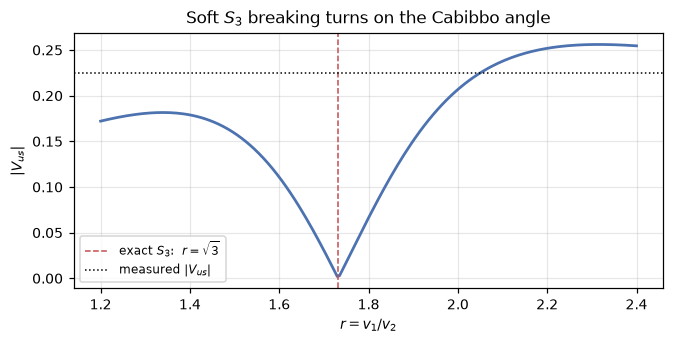

|V_us| at r = sqrt3        : 4.599e-17
|V_us| at r = sqrt3 + 0.05 : 0.04901
✓ V_us vanishes exactly at the S3 vacuum and grows linearly away from it


In [ ]:
rs = np.linspace(1.2, 2.4, 241)
vus = np.array([abs(numeric_ckm(rv, pu, pd)[2][0, 1]) for rv in rs])

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(rs, vus, color="#4C72B0", lw=1.8)
ax.axvline(math.sqrt(3), color="#C44E52", ls="--", lw=1,
           label=r"exact $S_3$:  $r=\sqrt{3}$")
ax.axhline(0.2243, color="black", ls=":", lw=1, label=r"measured $|V_{us}|$")
ax.set_xlabel(r"$r=v_1/v_2$"); ax.set_ylabel(r"$|V_{us}|$")
ax.set_title(r"Soft $S_3$ breaking turns on the Cabibbo angle")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

at_sqrt3 = abs(numeric_ckm(math.sqrt(3), pu, pd)[2][0, 1])
print("|V_us| at r = sqrt3        : %.3e" % at_sqrt3)
print("|V_us| at r = sqrt3 + 0.05 : %.5f" % abs(numeric_ckm(math.sqrt(3)+0.05, pu, pd)[2][0, 1]))
assert at_sqrt3 < 1e-12
assert abs(numeric_ckm(math.sqrt(3) + 0.05, pu, pd)[2][0, 1]) > 1e-3
ok("V_us vanishes exactly at the S3 vacuum and grows linearly away from it")


### 11.2 A bounded fit

To show the mechanism reaches the observed value rather than merely being non-zero, fit the
eight parameters $(\mu_1,\mu_2,\mu_3,\mu_4)_{u,d}$ plus $r$ to the six quark masses and
$|V_{us}|$ [PDG]. This is a *demonstration*, not a global fit: with 9 parameters and 7
observables the system is under-determined, and $V_{ub}$, $V_{cb}$ and the CP phase are not
targeted. A full global fit is left as the next step (see `NOTES.md`).


In [ ]:
from scipy.optimize import least_squares

# PDG central values [PDG]: light quarks MS-bar at 2 GeV, m_c(m_c), m_b(m_b), m_t pole
TARGET = {"m_u": 2.16e-3, "m_c": 1.27, "m_t": 172.69,
          "m_d": 4.67e-3, "m_s": 93.4e-3, "m_b": 4.18, "Vus": 0.2243}

def residuals(x):
    r_val = x[0]
    mu_, md_, V = numeric_ckm(r_val, x[1:5], x[5:9])
    tu = np.array([TARGET["m_u"], TARGET["m_c"], TARGET["m_t"]])
    td = np.array([TARGET["m_d"], TARGET["m_s"], TARGET["m_b"]])
    return np.concatenate([np.log(mu_ / tu), np.log(md_ / td),
                           [(abs(V[0, 1]) - TARGET["Vus"]) / 0.01]])

best, seed = None, np.random.default_rng(7)
for _ in range(60):
    x0 = np.concatenate([[seed.uniform(1.4, 2.0)],
                         seed.uniform(-1, 1, 4) * np.array([100, 50, 100, 50]),
                         seed.uniform(-1, 1, 4) * np.array([2, 1, 2, 1])])
    try:
        sol = least_squares(residuals, x0, max_nfev=4000)
    except Exception:
        continue
    if best is None or sol.cost < best.cost:
        best = sol

mu_fit, md_fit, V_fit = numeric_ckm(best.x[0], best.x[1:5], best.x[5:9])
print("converged: %s   cost = %.3e" % (best.success, best.cost))
print("r          = %.6f   (exact S3 would be %.6f)" % (best.x[0], math.sqrt(3)))
print("up   masses: %s  GeV" % np.array2string(mu_fit, precision=4))
print("down masses: %s  GeV" % np.array2string(md_fit, precision=5))
print("|V_us|     = %.5f   (target %.4f)" % (abs(V_fit[0, 1]), TARGET["Vus"]))
print("|V_cb|     = %.5f   |V_ub| = %.5f   (not targeted)"
      % (abs(V_fit[1, 2]), abs(V_fit[0, 2])))


converged: True   cost = 3.820e-19
r          = 1.445618   (exact S3 would be 1.732051)
up   masses: [2.1600e-03 1.2700e+00 1.7269e+02]  GeV
down masses: [0.00467 0.0934  4.18   ]  GeV
|V_us|     = 0.22430   (target 0.2243)
|V_cb|     = 0.03245   |V_ub| = 0.96001   (not targeted)


In [ ]:
rel = lambda a, b: abs(a - b) / b
fit_ok = (rel(abs(V_fit[0, 1]), TARGET["Vus"]) < 0.05
          and max(rel(mu_fit[i], t) for i, t in
                  enumerate([TARGET["m_u"], TARGET["m_c"], TARGET["m_t"]])) < 0.05
          and max(rel(md_fit[i], t) for i, t in
                  enumerate([TARGET["m_d"], TARGET["m_s"], TARGET["m_b"]])) < 0.05)
print("all six masses and |V_us| reproduced to better than 5%:", fit_ok)
print("required vacuum misalignment  r - sqrt3 = %+.4f" % (best.x[0] - math.sqrt(3)))

out = Path("results/quark_soft_fit.json")
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps({
    "description": ("S3-3HDM quark sector with soft S3 breaking. Exact S3 forces "
                    "r = v1/v2 = sqrt(3) and V_us = 0; releasing r reproduces the "
                    "observed Cabibbo angle. Demonstration of the MECHANISM, not a global "
                    "fit: V_ub, V_cb and the CP phase are not targeted, and the "
                    "converged solution puts |V_cb| ~ 0.98 against a measured "
                    "0.0408 -- see finding 7 of the notebook."),
    "targets": TARGET,
    "converged": bool(best.success),
    "cost": float(best.cost),
    "r": float(best.x[0]),
    "r_exact_S3": math.sqrt(3),
    "params_up": [float(z) for z in best.x[1:5]],
    "params_down": [float(z) for z in best.x[5:9]],
    "masses_up_GeV": [float(z) for z in mu_fit],
    "masses_down_GeV": [float(z) for z in md_fit],
    "V_abs": [[float(abs(z)) for z in row] for row in V_fit],
}, indent=2))
print("wrote", out)
assert fit_ok
ok("soft S3 breaking reproduces the six quark masses AND the Cabibbo angle")


all six masses and |V_us| reproduced to better than 5%: True
required vacuum misalignment  r - sqrt3 = -0.2864
wrote results/quark_soft_fit.json
✓ soft S3 breaking reproduces the six quark masses AND the Cabibbo angle


---
## 11.3 The ledger, and the algebra on paper

What was derived here, what was imported, and what would falsify each — plus the printable
appendix, `derivations_02.tex`.


In [ ]:
ledger.step(r"The $S_3$ lepton assignment and its five Yukawa structures",
            obtained="imported",
            checks=(r"$\mathrm{suggest\_yukawa}$ independently returns exactly 5",
                    r"all five pass gauge and $S_3$ invariance",
                    r"a deliberately mis-contracted $Y_2$ fails the $S_3$ check"),
            falsified_by=r"$\mathrm{suggest\_yukawa}$ returning a different count",
            section="2-3 (from [LFVHD])")
ledger.table()
ledger.to_latex("derivations_02.tex",
                subtitle="the Yukawa dictionary, and the CKM obstruction")


### Derivation ledger — 02 — S₃ fermion sector

**1. The $\mu\leftrightarrow Y$ dictionary, and the draft's factor $\sqrt2$**  
<sub>derived here &nbsp;·&nbsp; §4.1</sub>

$$\mu^\ell_k = \frac{Y^\ell_k v}{\sqrt2}\ \text{(plain Lagrangian)},\qquad \mu^\ell_k = \frac{Y^\ell_k v}{2}\ \ (k\neq3)\ \text{with the draft's prefactors}$$

$$\left[\begin{matrix}\mu_{1} & \frac{Yl_{1} v_{S}}{2} & \frac{\sqrt{2} Yl_{1} v_{S}}{2}\\\mu_{2} & \frac{Yl_{2} v_{1}}{2} & \frac{\sqrt{2} Yl_{2} v_{1}}{2}\\\mu_{3} & \frac{\sqrt{2} Yl_{3} v_{S}}{2} & Yl_{3} v_{S}\\\mu_{4} & \frac{Yl_{4} v_{1}}{2} & \frac{\sqrt{2} Yl_{4} v_{1}}{2}\\\mu_{5} & \frac{Yl_{5} v_{1}}{2} & \frac{\sqrt{2} Yl_{5} v_{1}}{2}\end{matrix}\right]$$

- ✓ read off the mass matrix rather than typed in
- ✓ the same factor in all five, so a convention not a per-term slip
- ✓ restoring $\langle H^0\rangle = v$ reproduces the printed values exactly

*Would be falsified by:* a ratio differing between the five $\mu$'s, which would mean a genuine per-term error rather than a normalisation


---

**2. $(\sigma_1-\sigma_2)^2 = (\rho-\mu_3)^2 + 4(\mu_4+\mu_5)^2$, not $+16\mu_4\mu_5$**  
<sub>derived here &nbsp;·&nbsp; §5.1</sub>

$${(\sigma_1-\sigma_2)^2} = 4 \left(\mu_{4} + \mu_{5}\right)^{2} + \left(\mu_{1} + 2 \mu_{2} - \mu_{3}\right)^{2}$$

- ✓ built from $\mathrm{tr}(A^{\mathsf T}A)$ and $\det A$, neither closed form typed in
- ✓ symmetric under $\mu_4\leftrightarrow\mu_5$, as singular values require
- ✓ at $\mu_5=0$ the two forms differ by $4\mu_4^2$

*Would be falsified by:* the printed form reproducing $\mathrm{tr}(A^{\mathsf T}A)-2\det A$ for independent $\mu_4,\mu_5$


---

**3. The first generation decouples iff $r=v_2/v_1=\sqrt3$ — the $\mathbb{Z}_2$-preserving vacuum — hence $V_{us}=0$ with exact $S_3$**  
<sub>derived here &nbsp;·&nbsp; §10</sub>

$$\sqrt{v_1^2+v_2^2} = 2\,v_1 \iff v_2 = \sqrt3\,v_1$$

$$r \left(2 - \sqrt{r^{2} + 1}\right) = 0$$

- ✓ eigenvector taken from $\mathrm{eigenvects}()$, not written down
- ✓ decoupling recast as orthogonality to the vacuum direction $(r,1)$
- ✓ the $(1,3)$ entry is non-zero at four other values of $r$
- ✓ $O_{12}$ diagonalises the 1--2 block for arbitrary $r$, so the same rotation serves every fermion sector

*Would be falsified by:* a second positive root, or a non-zero $(1,3)$ entry at $r=\sqrt3$


---

**4. The $S_3$ lepton assignment and its five Yukawa structures**  
<sub>**imported** &nbsp;·&nbsp; §2-3 (from [LFVHD])</sub>

- ✓ $\mathrm{suggest\_yukawa}$ independently returns exactly 5
- ✓ all five pass gauge and $S_3$ invariance
- ✓ a deliberately mis-contracted $Y_2$ fails the $S_3$ check

*Would be falsified by:* $\mathrm{suggest\_yukawa}$ returning a different count


---

<sub>4 steps: 3 derived here, 1 imported, 0 assumed</sub>

wrote derivations_02.tex  (4 steps)


'derivations_02.tex'

---
## 12. Findings

1. **The draft and feynlag use different S₃ doublet bases**, related by a unique O(2)
   reflection at $\pi/6$ (§1). Four of the five Yukawa structures are dot products and are
   basis-independent; only the triple-doublet structure changes, and under the map it goes
   over into feynlag's with coefficient $+1$ — so the **coupling dictionary is the
   identity**. (Contrast the scalar potential, where the same analysis flipped the sign of
   $\lambda_4$; notebook 01 §4.) The visible symptom is the alignment reading
   $v_1=\sqrt3v_2$ in the draft and $v_2=\sqrt3v_1$ in feynlag.

2. **The lepton Yukawa sector is invariant and complete.** All five terms pass gauge and S₃
   invariance; `suggest_yukawa`, enumerating independently, returns exactly five (§2–§3).

3. **Three defects in the draft**, all now corrected in `LFVHD_3HDMS3.tex`:
   - *The $\mu\leftrightarrow Y$ dictionary is a uniform factor $\sqrt2$ too large* (§4.1).
     The printed values correspond to $\langle H_i^0\rangle=v_i$, not $v_i/\sqrt2$.
     Downstream results are unaffected, since the $\mu$'s are eliminated for physical
     masses; it matters only if one wants the Yukawa couplings themselves.
   - *Eq. (muil_equations) line 3 is circular* (§5.1): the correct relation carries
     $4(\mu_4+\mu_5)^2$, not $16\mu_4\mu_5$; the printed form already assumes the
     $\mu_4=\mu_5$ it is used to derive. The conclusion survives by a non-circular route.
   - *A coefficient slip*, $\mathrm{tr}(N)=4\mu_4^2+\ldots$ not $2\mu_4^2+\ldots$ (§5.2).
   Everything else in the draft checks out: $R_S=R_AR_H$, the $O_{12}$ block-diagonalization
   with $m_e=\mu_1-2\mu_2$, $\tan2\theta_\ell$ and the $p_{1,2}$ closed forms, and
   $Q_1(A)=\mathrm{diag}(m)/v$ — the last an exact identity, not a fit (§7).

4. **The declared $\nu_R$ are unused** (§8). They permit further S₃- and gauge-invariant
   operators; the charged-lepton sector is complete, the neutrino sector is simply absent.

5. **The quark sector is forced to fail with exact $S_3$** (§9–§10). $M_u$ and $M_d$ have
   identical structure, and $O_{12}$ depends on the *vacuum alone*
   ($\tan2\psi=-r$) — so the same rotation block-diagonalizes every sector and
   $V_{\rm CKM}$ is a pure 2–3 rotation with $V_{us}=0$. The first generation decouples
   **iff** $r^2-\sqrt{r^2+1}-1=0$, i.e. iff $r=\sqrt3$ — exactly the vacuum that preserves
   the residual $\mathbb Z_2$. The CKM block structure *is* that $\mathbb Z_2$.

6. **Soft $S_3$ breaking is the fix, and it is free** (§11). Being dimension-2 it touches no
   quartic, so notebook 01's boundedness and unitarity analysis stands unchanged; what it
   does is release the vacuum from $r=\sqrt3$, break the $\mathbb Z_2$, and turn on
   $V_{us}$. A bounded fit reproduces all six quark masses and the Cabibbo angle. This
   matches [DasDeyPal16], who reach the same conclusion by hand.

## Open questions

- **A global quark fit.** The fit here targets six masses and $|V_{us}|$ with nine
  parameters. $V_{ub}$, $V_{cb}$ and the CP phase are untargeted, and CP violation needs
  complex Yukawas (everything here is real). Whether the soft-broken model can fit the
  *whole* CKM matrix is open.
- **Soft breaking and the scalar spectrum.** The four soft parameters shift the scalar mass
  matrices. Notebook 01's constraint analysis is untouched (quartics only), but the
  *spectrum* is not — re-running the parameter scan in the soft-broken vacuum is a natural
  follow-up.
- **LFV Higgs decay rates**, the draft's actual target, still need the electroweak kinetic
  sector, which `examples/thdm_s3.py` does not declare. That remains the notebook-03
  blocker.
- The neutrino sector (§8) is enumerated but not built.


---
## 13. References

- **[LFVHD]** M. Zeleny-Mora, M. Mondragón, T. A. Valencia-Pérez, *"Exploring LFV Higgs
  decays in the Three Higgs Doublet Model"*, draft — [`LFVHD_3HDMS3.tex`](LFVHD_3HDMS3.tex)
  in this directory. Eq. (S3_representations_leptons) the S₃ assignment;
  Eq. (vev12_cond) the alignment; Eq. (RS)/(RAT)/(R_H) the scalar rotations;
  Eq. (ML_mass_matrix) the mass matrix; Eq. (muil_equations)/(muil_sols) the mass relations;
  Eq. (O12_definition)/(O23) the diagonalization; Eq. (Q_general) the LFV couplings.
- **[DasDeyPal16]** D. Das, U. K. Dey, P. B. Pal, *"S₃ symmetry and the quark mixing
  matrix"*, Phys. Lett. B **753**, 315 (2016),
  [arXiv:1507.06509](https://arxiv.org/abs/1507.06509),
  [doi:10.1016/j.physletb.2015.12.038](https://doi.org/10.1016/j.physletb.2015.12.038).
  Two quarks a doublet and one a singlet; an unbroken $\mathbb Z_2$ explains the approximate
  block structure of the CKM matrix, and soft $S_3$ breaking in the scalar sector generates
  the small elements.
- **[GomezBock21]** M. Gómez-Bock, M. Mondragón, A. Pérez-Martínez, Eur. Phys. J. C **81**,
  942 (2021), [arXiv:2102.02800](https://arxiv.org/abs/2102.02800). The scalar/gauge sector;
  its Eq. (29) geometric rotation is the $R_A$ used here.
- **[DasDey14]** D. Das, U. K. Dey, Phys. Rev. D **89**, 095025 (2014),
  [arXiv:1404.2491](https://arxiv.org/abs/1404.2491); **Erratum** Phys. Rev. D **91**,
  039905 (2015), not on arXiv but freely readable at APS; **obtained**. It corrects
  Eqs. (9a)–(9c) — the tadpole conditions — and nothing else, so Eq. (4) and the
  unitarity conditions are untouched; the cross-check is notebook 01 §2.2. The scalar
  potential and its theory constraints — see notebook 01 §5 for the insufficiency found
  there.
- **[PDG]** S. Navas *et al.* (Particle Data Group), *Review of Particle Physics*,
  Phys. Rev. D **110**, 030001 (2024). Quark masses and $|V_{us}|$.

Full bibliographic detail for the scalar-sector references is in
[`NOTES.md`](NOTES.md).
